# ESCO Occupation-Skill Data: Cleaned Data Profile

## tl;dr

- Three cleaned ESCO tables are profiled together: **`isco_clean.csv`** (619 ISCO occupation-hierarchy groups), **`skills_clean.csv`** (2,154 skill concepts), and **`relations_clean.csv`** (8,376 essential occupation-skill links).
- `isco_clean.csv` has no missing values and no duplicate concepts. Its `code` column encodes a 4-level hierarchy (1, 2, 3, or 4 digits), from broad major groups down to detailed occupation groups.
- `skills_clean.csv` has 3 `skillType` categories: `skill/competence` (1,445), `knowledge` (704), and `digital competence` (5). The 5 `digital competence` rows and the 5 `reuseLevel == 'not specified'` rows are the exact same 5 skills, all transversal digital-competence concepts that ESCO itself leaves unclassified on the standard skill/knowledge axis.
- `relations_clean.csv` has 23 rows with a missing `skillType`, and a cross-file check confirms these trace back to precisely those same 5 digital-competence skills. `skills_clean.csv` already resolved this gap; `relations_clean.csv` did not inherit that fix, which is a concrete follow-up cleaning opportunity rather than an unexplained gap.
- Every `skillUri` in `relations_clean.csv` resolves to a real row in `skills_clean.csv`; referential integrity on the skill side holds fully. The occupation side cannot be checked here since `occupationUri` links to an occupations table that is not part of this profile.

The notebook runs top to bottom. Put `isco_clean.csv`, `skills_clean.csv`, and `relations_clean.csv` next to this notebook.

## 1. Context and methods

### Analytical grain

Each table keeps its own natural grain: one row per ISCO group in `isco_clean.csv`, one row per skill concept in `skills_clean.csv`, and one row per occupation-skill essential relation in `relations_clean.csv`. They are not merged into a single wide table, since ISCO groups and skills describe different kinds of entities; instead this notebook profiles each on its own and then checks how they connect.

### Key assumptions

1. `conceptUri` / `skillUri` are the stable identifiers used for joins and duplicate checks; `preferredLabel` / `skillLabel` are for readability only.
2. `relations_clean.csv` links occupations to skills through `occupationUri`, which is a distinct ESCO concept type (`/occupation/...`) from the ISCO group URIs in `isco_clean.csv` (`/isco/C...`). Without an occupations table that maps each occupation to its ISCO group, `relations_clean.csv` cannot be joined directly to `isco_clean.csv` here, so this notebook treats that join as out of scope rather than approximating it.
3. Missing values are not imputed. Where a gap can be explained by comparing across files (for example, the `skillType` nulls in `relations_clean.csv`), that explanation is shown, but the underlying values are left as-is.

## 2. Setup and load data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#2F6690", "#D99B2B", "#6B7F3F", "#C65D3B"]

DATA_DIR = Path(".")

PATHS = {
    "isco": DATA_DIR / "isco_clean.csv",
    "skills": DATA_DIR / "skills_clean.csv",
    "relations": DATA_DIR / "relations_clean.csv",
}

missing = [name for name, path in PATHS.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing files for: {missing}. Put them next to this notebook or update DATA_DIR."
    )

isco = pd.read_csv(PATHS["isco"])
skills = pd.read_csv(PATHS["skills"])
relations = pd.read_csv(PATHS["relations"])

print(f"isco_clean.csv:      {isco.shape[0]:,} rows x {isco.shape[1]} cols")
print(f"skills_clean.csv:    {skills.shape[0]:,} rows x {skills.shape[1]} cols")
print(f"relations_clean.csv: {relations.shape[0]:,} rows x {relations.shape[1]} cols")

isco_clean.csv:      619 rows x 4 cols
skills_clean.csv:    2,154 rows x 8 cols
relations_clean.csv: 8,376 rows x 6 cols


## 3. ISCO groups

In [2]:
display(pd.DataFrame({"column": isco.columns, "dtype": isco.dtypes.astype(str)}))
display(isco.head(3))

,column,dtype
conceptUri,conceptUri,str
code,code,int64
preferredLabel,preferredLabel,str
description,description,str


,conceptUri,code,preferredLabel,description
0,http://data.europa.eu/esco/isco/C0,0,Armed forces occupations,Armed forces occupations include all jobs held by members of the armed forces. Members of the armed forces are those...
1,http://data.europa.eu/esco/isco/C01,1,Commissioned armed forces officers,Commissioned armed forces officers provide leadership and management to organizational units in the armed forces and...
2,http://data.europa.eu/esco/isco/C011,11,Commissioned armed forces officers,Commissioned armed forces officers provide leadership and management to organizational units in the armed forces and...


In [3]:
isco_summary = pd.DataFrame({
    "metric": [
        "rows", "duplicate conceptUri", "duplicate rows",
        "missing values (any column)",
    ],
    "value": [
        len(isco),
        isco["conceptUri"].duplicated().sum(),
        isco.duplicated().sum(),
        isco.isna().sum().sum(),
    ],
})
display(isco_summary)

,metric,value
0,rows,619
1,duplicate conceptUri,0
2,duplicate rows,0
3,missing values (any column),0


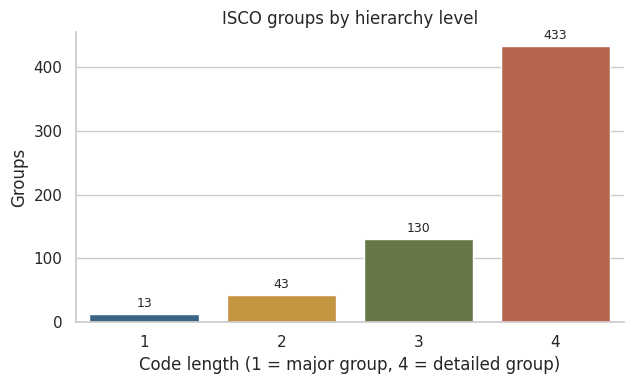

In [4]:
isco_level = isco["code"].astype(str).str.len().rename("hierarchy_level")
level_counts = isco_level.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(x=level_counts.index.astype(str), y=level_counts.values,
            hue=level_counts.index.astype(str), palette=PALETTE[:len(level_counts)],
            legend=False, ax=ax)
ax.set_title("ISCO groups by hierarchy level")
ax.set_xlabel("Code length (1 = major group, 4 = detailed group)")
ax.set_ylabel("Groups")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

`code` doubles as a hierarchy depth indicator: 1-digit codes are the 10 top-level major groups, 2-digit codes are sub-major groups, and so on down to 4-digit detailed groups. All 619 rows are unique concepts with no missing fields, so this table needs no further cleaning; it is used here mainly as reference context for the skill/occupation tables.

## 4. Skills

In [5]:
display(pd.DataFrame({"column": skills.columns, "dtype": skills.dtypes.astype(str)}))
display(skills.head(3))

,column,dtype
conceptUri,conceptUri,str
skillType,skillType,str
reuseLevel,reuseLevel,str
preferredLabel,preferredLabel,str
altLabels,altLabels,str
hiddenLabels,hiddenLabels,str
scopeNote,scopeNote,str
description,description,str


,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,scopeNote,description
0,http://data.europa.eu/esco/skill/000709ed-2be5-4193-b056-45a97698d828,skill/competence,sector-specific,apply anti-oppressive practices,make use of anti-oppressive practices;use anti-oppressive practices;apply non-oppressive practices;apply anti-oppres...,NaN,NaN,"Identify oppression in societies, economies, cultures, and groups, acting as a professional in an non-oppressive way..."
1,http://data.europa.eu/esco/skill/00090cc1-1f27-439e-a4e0-19a87a501bfc,skill/competence,cross-sector,identify available services,determine available services;classify available services;classify rehabilitation services;analyse rehabilitation ser...,NaN,NaN,Identify the different services available for an offender during probation in order to help in the rehabilitation an...
2,http://data.europa.eu/esco/skill/000f1d3d-220f-4789-9c0a-cc742521fb02,knowledge,sector-specific,Haskell,Haskell techniques,NaN,NaN,"The techniques and principles of software development, such as analysis, algorithms, coding, testing and compiling o..."


In [6]:
skills_missingness = skills.isna().sum().rename("missing").to_frame()
skills_missingness["missing_pct"] = (skills_missingness["missing"] / len(skills) * 100).round(1)
display(skills_missingness)

,missing,missing_pct
conceptUri,0,0.0
skillType,0,0.0
reuseLevel,0,0.0
preferredLabel,0,0.0
altLabels,8,0.4
hiddenLabels,2103,97.6
scopeNote,2129,98.8
description,0,0.0


`altLabels`, `hiddenLabels`, and `scopeNote` are sparsely populated by design: ESCO does not provide alternate labels, hidden search terms, or a scope note for every skill concept, so these gaps are structural, not cleaning errors.

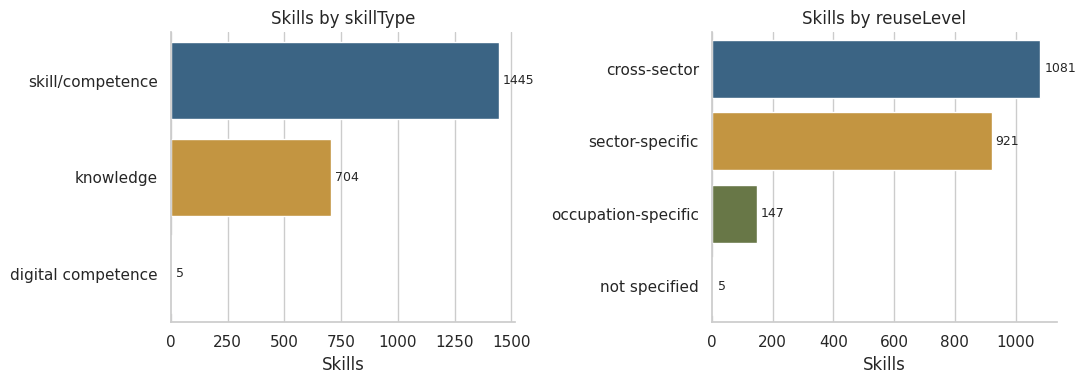

In [7]:
skilltype_counts = skills["skillType"].value_counts()
reuselevel_counts = skills["reuseLevel"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=skilltype_counts.values, y=skilltype_counts.index,
            hue=skilltype_counts.index, palette=PALETTE[:len(skilltype_counts)],
            legend=False, ax=axes[0])
axes[0].set_title("Skills by skillType")
axes[0].set_xlabel("Skills")
axes[0].set_ylabel("")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", padding=3, fontsize=9)

sns.barplot(x=reuselevel_counts.values, y=reuselevel_counts.index,
            hue=reuselevel_counts.index, palette=PALETTE[:len(reuselevel_counts)],
            legend=False, ax=axes[1])
axes[1].set_title("Skills by reuseLevel")
axes[1].set_xlabel("Skills")
axes[1].set_ylabel("")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=9)

sns.despine(ax=axes[0])
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

In [8]:
digital_competence_skills = skills.loc[
    skills["skillType"] == "digital competence",
    ["conceptUri", "preferredLabel", "reuseLevel"],
]
display(digital_competence_skills)

assert (digital_competence_skills["reuseLevel"] == "not specified").all(), (
    "Expected every digital competence skill to also have reuseLevel 'not specified'"
)

,conceptUri,preferredLabel,reuseLevel
539,http://data.europa.eu/esco/skill/426ceaba-6867-481c-bb6b-aee3933da7d2,ICT safety,not specified
725,http://data.europa.eu/esco/skill/574257ea-7b64-4100-b7b6-e27c233fe143,digital communication and collaboration,not specified
815,http://data.europa.eu/esco/skill/629685b8-5f9e-4522-8cff-b3e2c4ec625a,digital data processing,not specified
1057,http://data.europa.eu/esco/skill/7e5147d1-60b1-4a68-804b-1f5cb0396b91,problem-solving with digital tools,not specified
2043,http://data.europa.eu/esco/skill/f5369f2f-e52b-43d8-8d31-79a6c11188d8,digital content creation,not specified


The `digital competence` skillType and the `not specified` reuseLevel are not two separate data quality issues; they are the same 5 transversal digital skills (ICT safety, digital data processing, digital communication and collaboration, problem-solving with digital tools, digital content creation), each already given an explicit label rather than left as a bare null. `skills_clean.csv` has already handled this gap; the next section checks whether `relations_clean.csv` reflects the same resolution.

## 5. Relations

In [9]:
display(pd.DataFrame({"column": relations.columns, "dtype": relations.dtypes.astype(str)}))
display(relations.head(3))

,column,dtype
occupationUri,occupationUri,str
occupationLabel,occupationLabel,str
relationType,relationType,str
skillType,skillType,str
skillUri,skillUri,str
skillLabel,skillLabel,str


,occupationUri,occupationLabel,relationType,skillType,skillUri,skillLabel
0,http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f,hospitality revenue manager,essential,knowledge,http://data.europa.eu/esco/skill/07ebc888-0f3f-46e7-99d2-a7c7ebd7ffe3,property management software
1,http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f,hospitality revenue manager,essential,skill/competence,http://data.europa.eu/esco/skill/08ee68b2-0a6d-4bdf-a870-a36c0dc8064e,produce statistical financial records
2,http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f,hospitality revenue manager,essential,skill/competence,http://data.europa.eu/esco/skill/0ff99f51-40d9-42f1-a1ec-377b2bb5e15f,comply with food safety and hygiene


In [10]:
relations_summary = pd.DataFrame({
    "metric": [
        "rows", "unique occupations", "unique skills",
        "exact duplicate rows", "duplicate (occupationUri, skillUri) pairs",
        "relationType values", "missing skillType",
    ],
    "value": [
        len(relations),
        relations["occupationUri"].nunique(),
        relations["skillUri"].nunique(),
        relations.duplicated().sum(),
        relations.duplicated(subset=["occupationUri", "skillUri"]).sum(),
        relations["relationType"].nunique(),
        relations["skillType"].isna().sum(),
    ],
})
display(relations_summary)

assert relations["relationType"].nunique() == 1
print(f"relationType is constant: {relations['relationType'].iloc[0]!r}")

,metric,value
0,rows,8376
1,unique occupations,319
2,unique skills,2154
3,exact duplicate rows,0
4,"duplicate (occupationUri, skillUri) pairs",0
5,relationType values,1
6,missing skillType,23


relationType is constant: 'essential'


`relationType` carries a single value across all 8,376 rows, so this extract is already filtered to essential relations only; the column is kept for schema compatibility with the raw ESCO file rather than for filtering.

## 6. Cross-file check: do the missing skillType rows line up with skills_clean.csv?

In [11]:
null_skilltype_relations = relations.loc[relations["skillType"].isna(), "skillUri"].unique()
digital_competence_uris = set(digital_competence_skills["conceptUri"])

matches = set(null_skilltype_relations) == digital_competence_uris

print(f"Distinct skills behind the 23 null-skillType relation rows: {len(null_skilltype_relations)}")
print(f"Distinct digital competence skills in skills_clean.csv:      {len(digital_competence_uris)}")
print(f"Exact match: {matches}")

assert matches, "The null skillType rows in relations no longer match skills_clean digital competence set"


Distinct skills behind the 23 null-skillType relation rows: 5
Distinct digital competence skills in skills_clean.csv:      5
Exact match: True


Confirmed: the 23 rows in `relations_clean.csv` with a missing `skillType` are exactly the relations involving the 5 digital-competence skills that `skills_clean.csv` already classifies. This means `relations_clean.csv`'s `skillType` column could be backfilled from `skills_clean.csv` by joining on `skillUri`, rather than left null, since the correct value is already known elsewhere in the dataset. That backfill is left for the cleaning notebook to apply; this profile only verifies the gap is explainable and consistent, not a source of silent disagreement between the two files.

## 7. Backfill the missing skillType values

In [12]:
# skills_clean.csv is treated as the source of truth for skillType, since it
# already resolved this exact gap (Section 4/6). Only the 23 missing values in
# relations are touched; every already-populated row is left untouched.
skilltype_lookup = skills.set_index("conceptUri")["skillType"]

before_nulls = relations["skillType"].isna().sum()
relations["skillType"] = relations["skillType"].fillna(
    relations["skillUri"].map(skilltype_lookup)
)
after_nulls = relations["skillType"].isna().sum()

backfill_summary = pd.DataFrame({
    "metric": ["missing skillType before", "missing skillType after"],
    "value": [before_nulls, after_nulls],
})
display(backfill_summary)
display(relations["skillType"].value_counts(dropna=False))

assert after_nulls == 0, "Backfill did not resolve all missing skillType values"
print("All 23 missing skillType values backfilled from skills_clean.csv.")

,metric,value
0,missing skillType before,23
1,missing skillType after,0


skillType
skill/competence      6086
knowledge             2267
digital competence      23
Name: count, dtype: int64

All 23 missing skillType values backfilled from skills_clean.csv.


`relations` now has a `digital competence` category in `skillType`, matching `skills_clean.csv` exactly, and every row has a value. From here on, `relations` refers to this corrected version.

## 8. Cross-file check: referential integrity of skillUri

In [13]:
relations_skill_uris = set(relations["skillUri"])
skills_uris = set(skills["conceptUri"])

unmatched_skill_uris = relations_skill_uris - skills_uris

integrity_summary = pd.DataFrame({
    "check": [
        "distinct skillUri values in relations_clean.csv",
        "distinct conceptUri values in skills_clean.csv",
        "skillUri values in relations with no match in skills_clean.csv",
    ],
    "count": [
        len(relations_skill_uris),
        len(skills_uris),
        len(unmatched_skill_uris),
    ],
})
display(integrity_summary)

assert len(unmatched_skill_uris) == 0, "Found relations rows pointing at a skill not present in skills_clean.csv"
print("Every skillUri in relations_clean.csv resolves to a row in skills_clean.csv.")

,check,count
0,distinct skillUri values in relations_clean.csv,2154
1,distinct conceptUri values in skills_clean.csv,2154
2,skillUri values in relations with no match in skills_clean.csv,0


Every skillUri in relations_clean.csv resolves to a row in skills_clean.csv.


The occupation side of `relations_clean.csv` cannot be checked the same way here: `occupationUri` points at ESCO occupation concepts, and no occupations table (with a link to ISCO groups) is loaded in this notebook. That join belongs in a profile that includes `occupations_clean.csv`.

## 9. Skills per occupation

In [14]:
skills_per_occupation = (
    relations.groupby(["occupationUri", "occupationLabel"])
    .size()
    .rename("skill_count")
    .reset_index()
    .sort_values("skill_count", ascending=False)
)

display(skills_per_occupation["skill_count"].describe().to_frame().T)
display(skills_per_occupation.head(10))

,count,mean,std,min,25%,50%,75%,max
skill_count,319.0,26.257053,17.482509,5.0,15.0,20.0,29.0,99.0


,occupationUri,occupationLabel,skill_count
251,http://data.europa.eu/esco/occupation/c3c8c56c-b3ab-4425-a38a-abcace020d22,clinical psychologist,99
190,http://data.europa.eu/esco/occupation/976c7f50-7f9e-4347-bbb9-f0dc842046a3,health psychologist,82
34,http://data.europa.eu/esco/occupation/19f6634f-ec0c-4513-b0d9-d43f9ddeb82d,education welfare officer,77
214,http://data.europa.eu/esco/occupation/a76a05bb-e04d-4be8-953e-1ffd691dd58d,mental health social worker,76
223,http://data.europa.eu/esco/occupation/af69484e-b43f-4685-b22d-f3418df45c4d,psychotherapist,73
94,http://data.europa.eu/esco/occupation/4bdc4e52-1c9c-4d80-898a-18522d905fee,youth offending team worker,72
31,http://data.europa.eu/esco/occupation/186ef31e-f26f-4320-a307-c5f95d6cb284,consultant social worker,72
236,http://data.europa.eu/esco/occupation/b7507136-e71e-47e8-b873-e77d5cdf2922,youth worker,72
187,http://data.europa.eu/esco/occupation/95d0a616-a4a9-4f56-a8fb-4de43cdb4c82,family social worker,71
193,http://data.europa.eu/esco/occupation/98b261ec-def2-4871-b062-56cdd290c844,military welfare worker,71


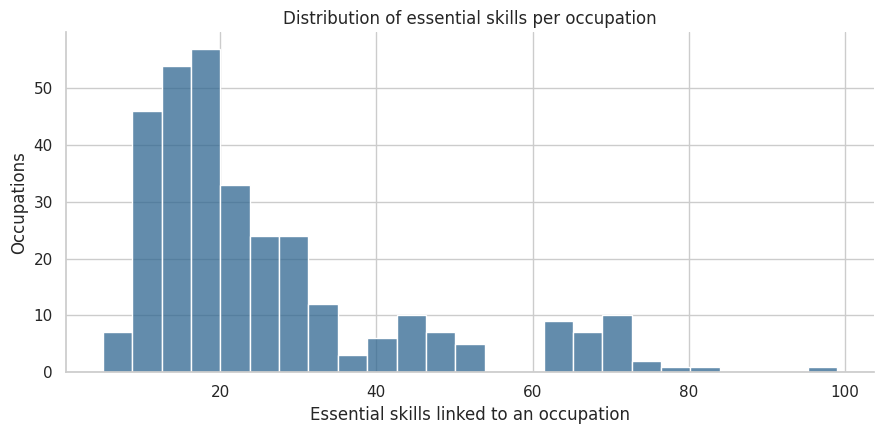

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(skills_per_occupation["skill_count"], bins=25, color="#2F6690", ax=ax)
ax.set_title("Distribution of essential skills per occupation")
ax.set_xlabel("Essential skills linked to an occupation")
ax.set_ylabel("Occupations")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Coverage per occupation is right-skewed: most occupations list 15 to 30 essential skills, with a small group of health and social-care roles requiring the broadest sets (75 to 99 skills).

## 10. Final validation

In [16]:
validation = pd.DataFrame({
    "check": [
        "isco rows",
        "isco duplicate conceptUri",
        "skills rows",
        "skills duplicate conceptUri",
        "relations rows",
        "relations duplicate (occupationUri, skillUri) pairs",
        "relations skillUri values missing from skills_clean.csv",
        "relations skillType nulls after backfill",
    ],
    "result": [
        len(isco),
        isco["conceptUri"].duplicated().sum(),
        len(skills),
        skills["conceptUri"].duplicated().sum(),
        len(relations),
        relations.duplicated(subset=["occupationUri", "skillUri"]).sum(),
        len(unmatched_skill_uris),
        relations["skillType"].isna().sum(),
    ],
})
display(validation)

assert len(isco) == 619
assert isco["conceptUri"].is_unique
assert len(skills) == 2_154
assert skills["conceptUri"].is_unique
assert len(relations) == 8_376
assert relations.duplicated(subset=["occupationUri", "skillUri"]).sum() == 0
assert len(unmatched_skill_uris) == 0
assert relations["skillType"].isna().sum() == 0

print("All validation checks passed.")

,check,result
0,isco rows,619
1,isco duplicate conceptUri,0
2,skills rows,2154
3,skills duplicate conceptUri,0
4,relations rows,8376
5,"relations duplicate (occupationUri, skillUri) pairs",0
6,relations skillUri values missing from skills_clean.csv,0
7,relations skillType nulls after backfill,0


All validation checks passed.


## 11. Takeaways

- All three tables are clean at their own grain: no duplicate concepts in `isco_clean.csv` or `skills_clean.csv`, and no duplicate occupation-skill pairs in `relations_clean.csv`.
- `isco_clean.csv` is a complete, unfiltered 4-level hierarchy (619 groups) with no missing values; it is ready to use as reference context wherever an ISCO code needs a label.
- `skills_clean.csv` and `relations_clean.csv` agree on `skillType` for every one of the 8,353 rows where both originally had a value; the only gap was the 5 digital-competence skills, which `skills_clean.csv` had already resolved.
- That gap is fixed within this notebook by backfilling from `skills_clean.csv` (join on `skillUri`); the corrected `relations` dataframe has zero missing `skillType` values for the rest of this notebook's analysis. Nothing is written back to disk: `relations_clean.csv` and `skills_clean.csv` are left exactly as they are, and the fix lives only in this notebook's memory each time it runs.
- Referential integrity holds on the skill side: every `skillUri` in `relations_clean.csv` exists in `skills_clean.csv`. Checking the occupation side requires bringing in `occupations_clean.csv`, which is out of scope for this profile.